# Dataset Sintético de Evasão Escolar

Este notebook gera um dataset sintético com base em variáveis relacionadas à evasão escolar no ensino público do Distrito Federal. As variáveis foram definidas previamente e incluem dados do estudante, família, comunidade, escola e professores.

# Definição de evasão escolar

- Precisamos de uma definição clara de evasão escolar. Exemplo, faltou mais de 30 dias seguidos?! 
- O ideal é seguir a definição do MEC, que considera evasão escolar a falta não justificada por mais de 15 dias consecutivos, conforme ChatGPT (temos que confirmar e pegar a fonte).
- Ou podemos considerar uma definição razoável usada em outros trabalhos acadêmicos.

# Propriedades de atributos

- Precisamos definir melhor as propriedades de cada atributo para facilitar a síntese de dados. Exemplo:
  - Sexo: variável categórica (masculino, feminino, "não informado" ?). Qual a proporção de cada categoria? Se não houver, podemos usar dados do IBGE.
  - Idade: variável numérica. Qual a média, mediana e desvio padrão? OU proporção entre esses, considerando uma variável categórica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import truncnorm

# Configurações iniciais
n_alunos = 100000  # número de registros
np.random.seed(42)
random.seed(42)

In [2]:
sexos = ['Masculino', 'Feminino', 'Outro']
apoio_familiar_vals = ['Alto', 'Médio', 'Baixo']
comportamento_vals = ['Bom', 'Regular', 'Ruim']
aceitacao_vals = ['Alta', 'Média', 'Baixa']
expectativa_vals = ['Alta', 'Média', 'Baixa']
engajamento_vals = ['Alto', 'Moderado', 'Baixo']
infraestrutura_vals = ['Boa', 'Regular', 'Ruim']
material_vals = ['Completa', 'Parcial', 'Insuficiente']
flex_pedagogica_vals = ['Alta', 'Média', 'Baixa']
qualidade_pedagogica_vals = ['Boa', 'Regular', 'Ruim']

idades=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

In [3]:
proporcao_evasao = 0.059 # porcentagem de evasão

pesos_idades=[0.06, 0.06, 0.06, 0.06, 0.07, 0.10, 0.13, 0.14, 0.13, 0.07, 0.07, 0.07, 0.07]
pesos_idades_evadiu=[0.02, 0.02, 0.02, 0.02, 0.04, 0.09, 0.15, 0.18, 0.16, 0.06, 0.06, 0.06, 0.06]

In [25]:
def gerar_idade(evadiu:bool):
    if evadiu:
        return random.choices(idades, weights=pesos_idades_evadiu)[0]
    else:
        return random.choices(idades, weights=pesos_idades)[0]

def gerar_sexo(evadiu:bool):
    if evadiu:
        return random.choices(sexos, weights=[0.53, 0.45, 0.02])[0]
    else:
        return random.choices(sexos, weights=[0.46, 0.52, 0.02])[0]
    
def gerar_frequencia():
    media = 85
    desvio = 10

    a, b = (0 - media) / desvio, (100 - media) / desvio  # limites normalizados
    notas = truncnorm.rvs(a, b, loc=media, scale=desvio, size=n_alunos)
    return np.round(notas, 1)

def gerar_nota():
    distribuicao = {
        (0, 5): 0.25,   # 25% dos alunos com média até 5
        (5, 7): 0.35,   # 35% entre 5 e 7
        (7, 10): 0.40   # 40% entre 7 e 10
    }
    
    # selecionar faixa com base nas probabilidades
    faixas = list(distribuicao.keys())
    probs = list(distribuicao.values())
    faixa_escolhida = faixas[np.random.choice(len(faixas), p=probs)]
    
    # ordena nota uniforme dentro da faixa
    nota = np.random.uniform(faixa_escolhida[0], faixa_escolhida[1])
    
    return round(nota, 1) 

def gerar_niveis_socioeconomicos():

    distribuicao = {
        "Muito baixo": 0.10,
        "Baixo": 0.30,
        "Médio": 0.40,
        "Alto": 0.15,
        "Muito alto": 0.05
    }

    categorias = list(distribuicao.keys())
    probs = list(distribuicao.values())
    
    return np.random.choice(categorias, p=probs)

def gerar_renda():
    distribuicao = {
        (0,1): 0.05,
        (1,2): 0.35,
        (2,5): 0.45,
        (5,10): 0.10,
        (10, 20): 0.05
    }

    # escolher faixa com base nas probabilidades
    faixas = list(distribuicao.keys())
    probs = list(distribuicao.values())
    
    rendas = []
    for _ in range(n_alunos):
        faixa_escolhida = faixas[np.random.choice(len(faixas), p=probs)]
        renda_sm = np.random.uniform(faixa_escolhida[0], faixa_escolhida[1])
        salario_min = 1139.4
        renda_reais = renda_sm * salario_min
        rendas.append(round(renda_reais, 2))

    return rendas

def gerar_etapa_ensino(evadiu: bool):
    # todas as listas seguintes seguem essa ordem
    etapas = ["1° EF", "2° EF", "3° EF", "4° EF", "5° EF", "6° EF", \
              "7° EF", "8° EF", "9° EF", "1° EM", "2° EM", "3° EM"]

    # dados do censo escolar de 2023(ultimo ano disponivel c/ porcentagens de evasao)
    qtd_matriculas_etapas = np.array([38372, 40181, 44456, 38574, 39048, 40502, \
                    41175, 39062, 40068, 38888, 36626, 32076])
    total_matriculas = qtd_matriculas_etapas.sum()
    
    # distribuição da proporção de alunos por etapa
    distr_etapas = qtd_matriculas_etapas / total_matriculas

    percentual_evasao_etapa = np.array([0.002, 0.001, 0.002, 0.003, 0.004, 0.01,
                                       0.014, 0.018, 0.025, 0.04, 0.046, 0.03])
    
    # calcula a distribuição de abandonos (evadidos por etapa) e normaliza
    qtd_evadidos_por_etapa = qtd_matriculas_etapas * percentual_evasao_etapa
    total_evadidos = qtd_evadidos_por_etapa.sum()
    if total_evadidos <= 0:
        distr_etapas_evasao = distr_etapas.copy()
    else:
        distr_etapas_evasao = qtd_evadidos_por_etapa / total_evadidos

    # evadiu -> usar distribuição de evasão; não evadiu -> usar distribuição geral
    weights = distr_etapas_evasao if evadiu else distr_etapas
    return random.choices(etapas, weights=weights, k=1)[0]

def gerar_distancia():
    return round(abs(np.random.normal(2, 1)), 1)  

In [ ]:
def normalizar_probabilidades(probabilidades):
    soma = sum(probabilidades)
    return [p/soma for p in probabilidades]

# Probabilidades normalizadas
prob_raca_cor = normalizar_probabilidades([0.321, 0.037, 0.373, 0.004, 0.008, 0.255])
prob_localizacao = normalizar_probabilidades([0.9325, 0.0675])
prob_situacao_nao_evadido = normalizar_probabilidades([0.75, 0.20, 0.05])

In [31]:
serie_evasao:list[bool] = [random.choices([True, False], weights=[proporcao_evasao, 1 - proporcao_evasao])[0] for _ in range(n_alunos) ]

# Criação do DataFrame
df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'evasao': serie_evasao,  # atributo que eu tenho e quero estimar
    'sexo': [gerar_sexo(evadir) for evadir in serie_evasao],
    'idade': [gerar_idade(evadir) for evadir in serie_evasao],

    
    # Variáveis demográfica e administrativas
    'estudante_nis': np.random.choice([True, False], n_alunos, p=[0.3, 0.7]),
    'informou_nome_mae': np.random.choice([True, False], n_alunos, p=[0.95, 0.05]),
    'informou_nome_pai': np.random.choice([True, False], n_alunos, p=[0.7, 0.3]),
    'possui_deficiencia': np.random.choice([True, False], n_alunos, p=[0.05, 0.95]),
    'raca_cor': np.random.choice(
        ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarada'],
        n_alunos,
        p=prob_raca_cor # Gráfico Censo 2023 - Fundação Roberto Marinho
    ),
    'tipo_localizacao_endereco_estudante': np.random.choice(
        ['Urbana', 'Rural'],
        n_alunos,
        p=prob_localizacao 
    ),
    'situacao_consolidada_no_ano': np.random.choice(
        ['Aprovado', 'Reprovado', 'Evadido', 'Em andamento'],
        n_alunos,
        p=[0.7, 0.15, 0.1, 0.05]
    ),
    'etapa_ensino': [gerar_etapa_ensino(i) for i in serie_evasao],
    'repetente': np.random.choice([True, False], n_alunos, p=[0.047, 0.953]),
    'frequencia_escolar': gerar_frequencia(),    
    'notas_medias': [gerar_nota() for _ in range(n_alunos)],
    'nivel_socioeconomico': [gerar_niveis_socioeconomicos() for _ in range(n_alunos)],
    'renda_familiar': gerar_renda(),
    
    # Variáveis de contexto social e familiar
    'trabalha': np.random.choice([True, False], n_alunos, p=[0.15, 0.85]),
    'trabalho_domestico_excessivo': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'problemas_de_saude': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'violencia_domestica': np.random.choice([True, False], n_alunos, p=[0.05, 0.95]),
    'gravidez_na_adolescencia': np.random.choice([True, False], n_alunos, p=[0.03, 0.97]),
    'apoio_familiar': np.random.choice(apoio_familiar_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'comportamento_em_sala': np.random.choice(comportamento_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'aceitacao_pelos_pares': np.random.choice(aceitacao_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'necessita_assistencia_social': np.random.choice([True, False], n_alunos, p=[0.3, 0.7]),
    'expectativa_retorno': np.random.choice(expectativa_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'fator_desencadeador_presente': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'distancia_da_escola_km': [gerar_distancia() for _ in range(n_alunos)],
    'violencia_na_comunidade': np.random.choice([True, False], n_alunos, p=[0.2, 0.8]),
    'engajamento_com_a_escola': np.random.choice(engajamento_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    
    # Variáveis institucionais
    'infraestrutura_escolar': np.random.choice(infraestrutura_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'disponibilidade_material_didatico': np.random.choice(material_vals, n_alunos, p=[0.6, 0.3, 0.1]),
    'flexibilidade_pedagogica': np.random.choice(flex_pedagogica_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'qualidade_pedagogica_percebida': np.random.choice(qualidade_pedagogica_vals, n_alunos, p=[0.5, 0.3, 0.2])
})


In [32]:
def calcular_distorcao_idade_serie(df):
    # Dados: https://www.unicef.org/brazil/media/461/file/Panorama_da_distorcao_idade-serie_no_Brasil.pdf
    idade_ideal_por_etapa = {
        '1° EF': 6, '2° EF': 7, '3° EF': 8, '4° EF': 9, '5° EF': 10,
        '6° EF': 11, '7° EF': 12, '8° EF': 13, '9° EF': 14,
        '1° EM': 15, '2° EM': 16, '3° EM': 17
    }
    
    df['idade_ideal'] = df['etapa_ensino'].map(idade_ideal_por_etapa)
    df['diferenca_idade'] = df['idade'] - df['idade_ideal']
    
    conditions = [
        df['diferenca_idade'] <= -2,  # Muito adiantado
        df['diferenca_idade'] <= 1,   # Na idade correta
        df['diferenca_idade'] <= 2,   # Pequeno atraso
        df['diferenca_idade'] > 2     # Grande atraso
    ]
    choices = ['Muito adiantado', 'Tempo correto', 'Pequeno atraso', 'Grande atraso']
    df['distorcao_idade_serie'] = np.select(conditions, choices, default='Na idade')
    
    return df

df = calcular_distorcao_idade_serie(df)

In [33]:
# # Pontuação de risco
df['pontuacao_risco'] = (
     (100 - df['frequencia_escolar']) / 100 * 0.3 +
     (10 - df['notas_medias']) / 10 * 0.3 +
     df['repetente'].astype(int) * 0.1 +
     df['trabalha'].astype(int) * 0.1 +
     df['violencia_domestica'].astype(int) * 0.2
 )
df['pontuacao_risco'] = df['pontuacao_risco'] / df['pontuacao_risco'].max()

# # Evasão confirmada
df['evasao_confirmada'] = [np.random.rand() < r for r in df['pontuacao_risco']]

## Análise Exploratória

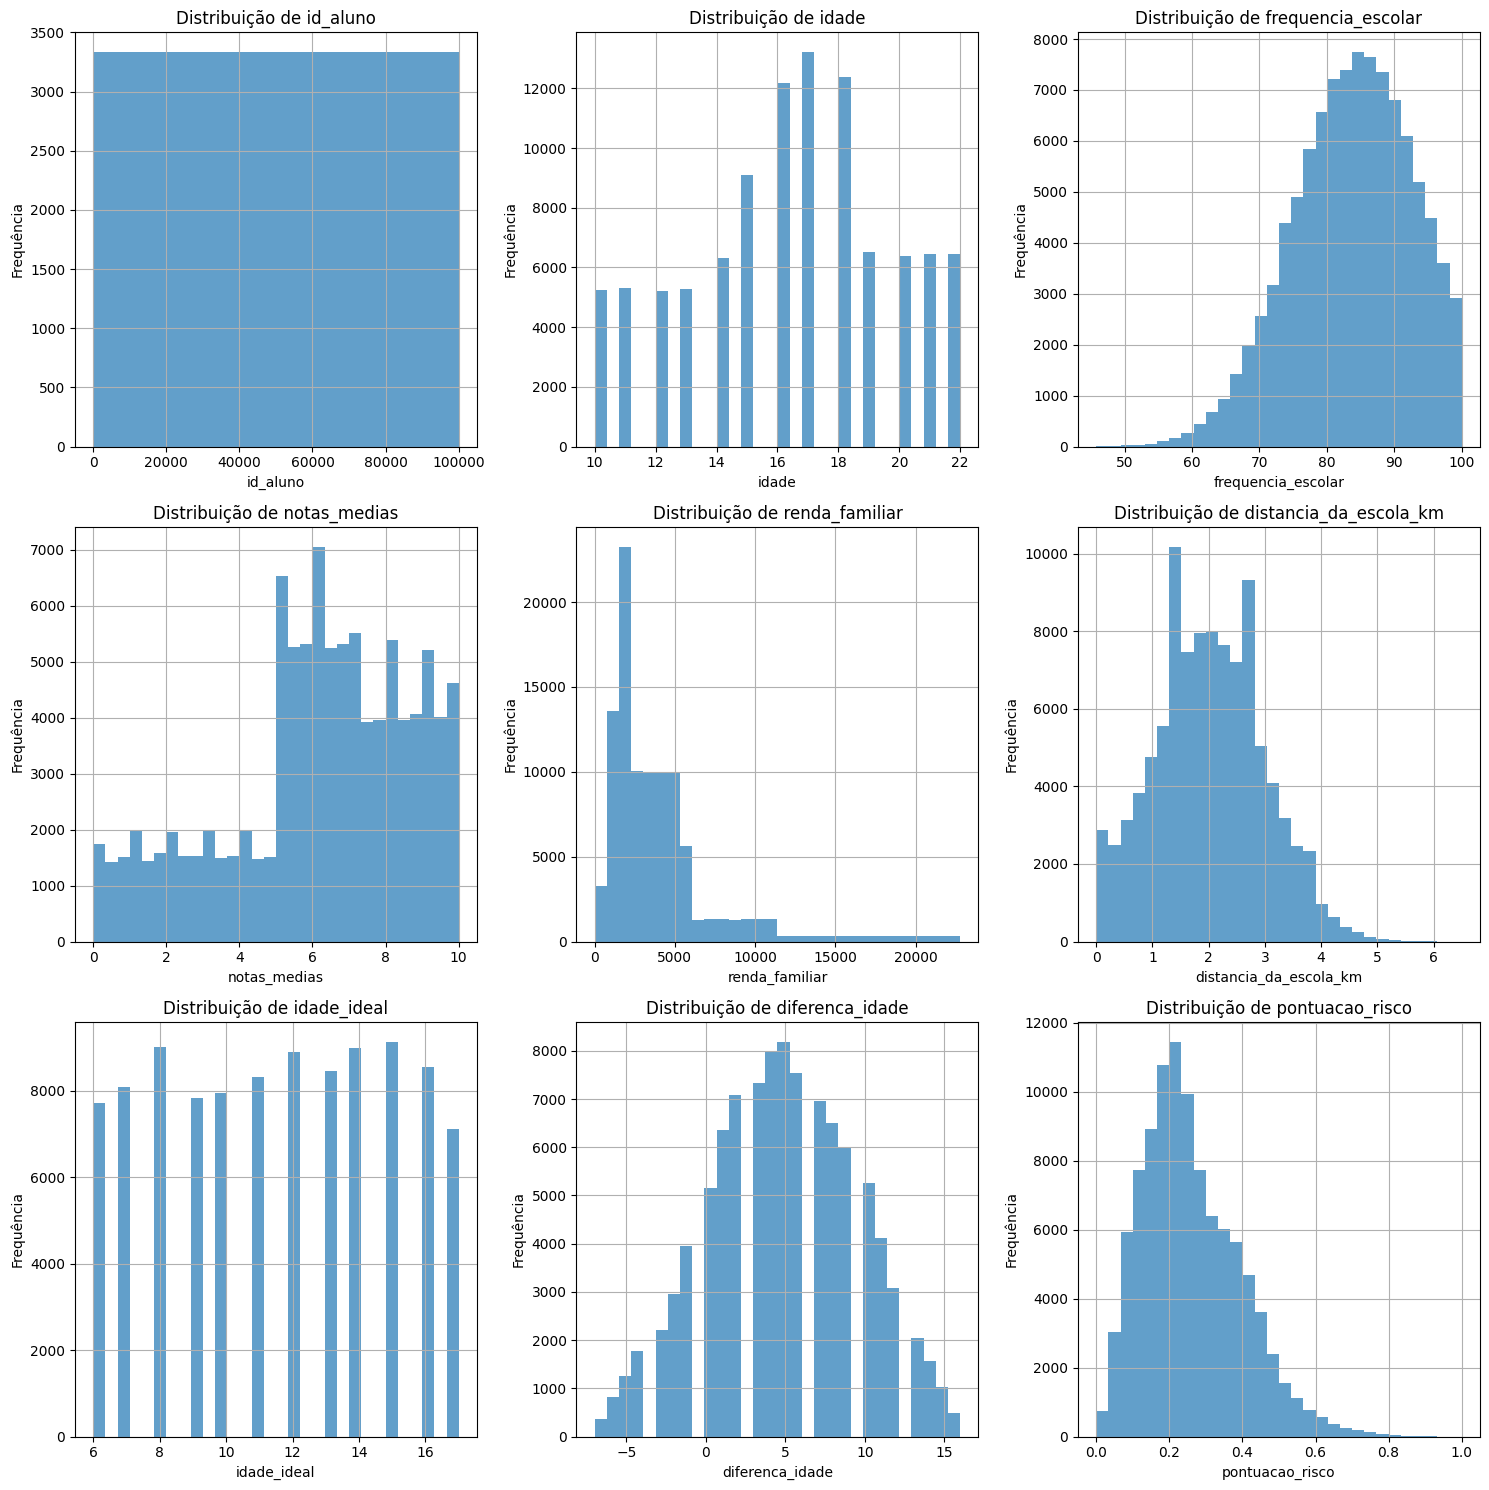

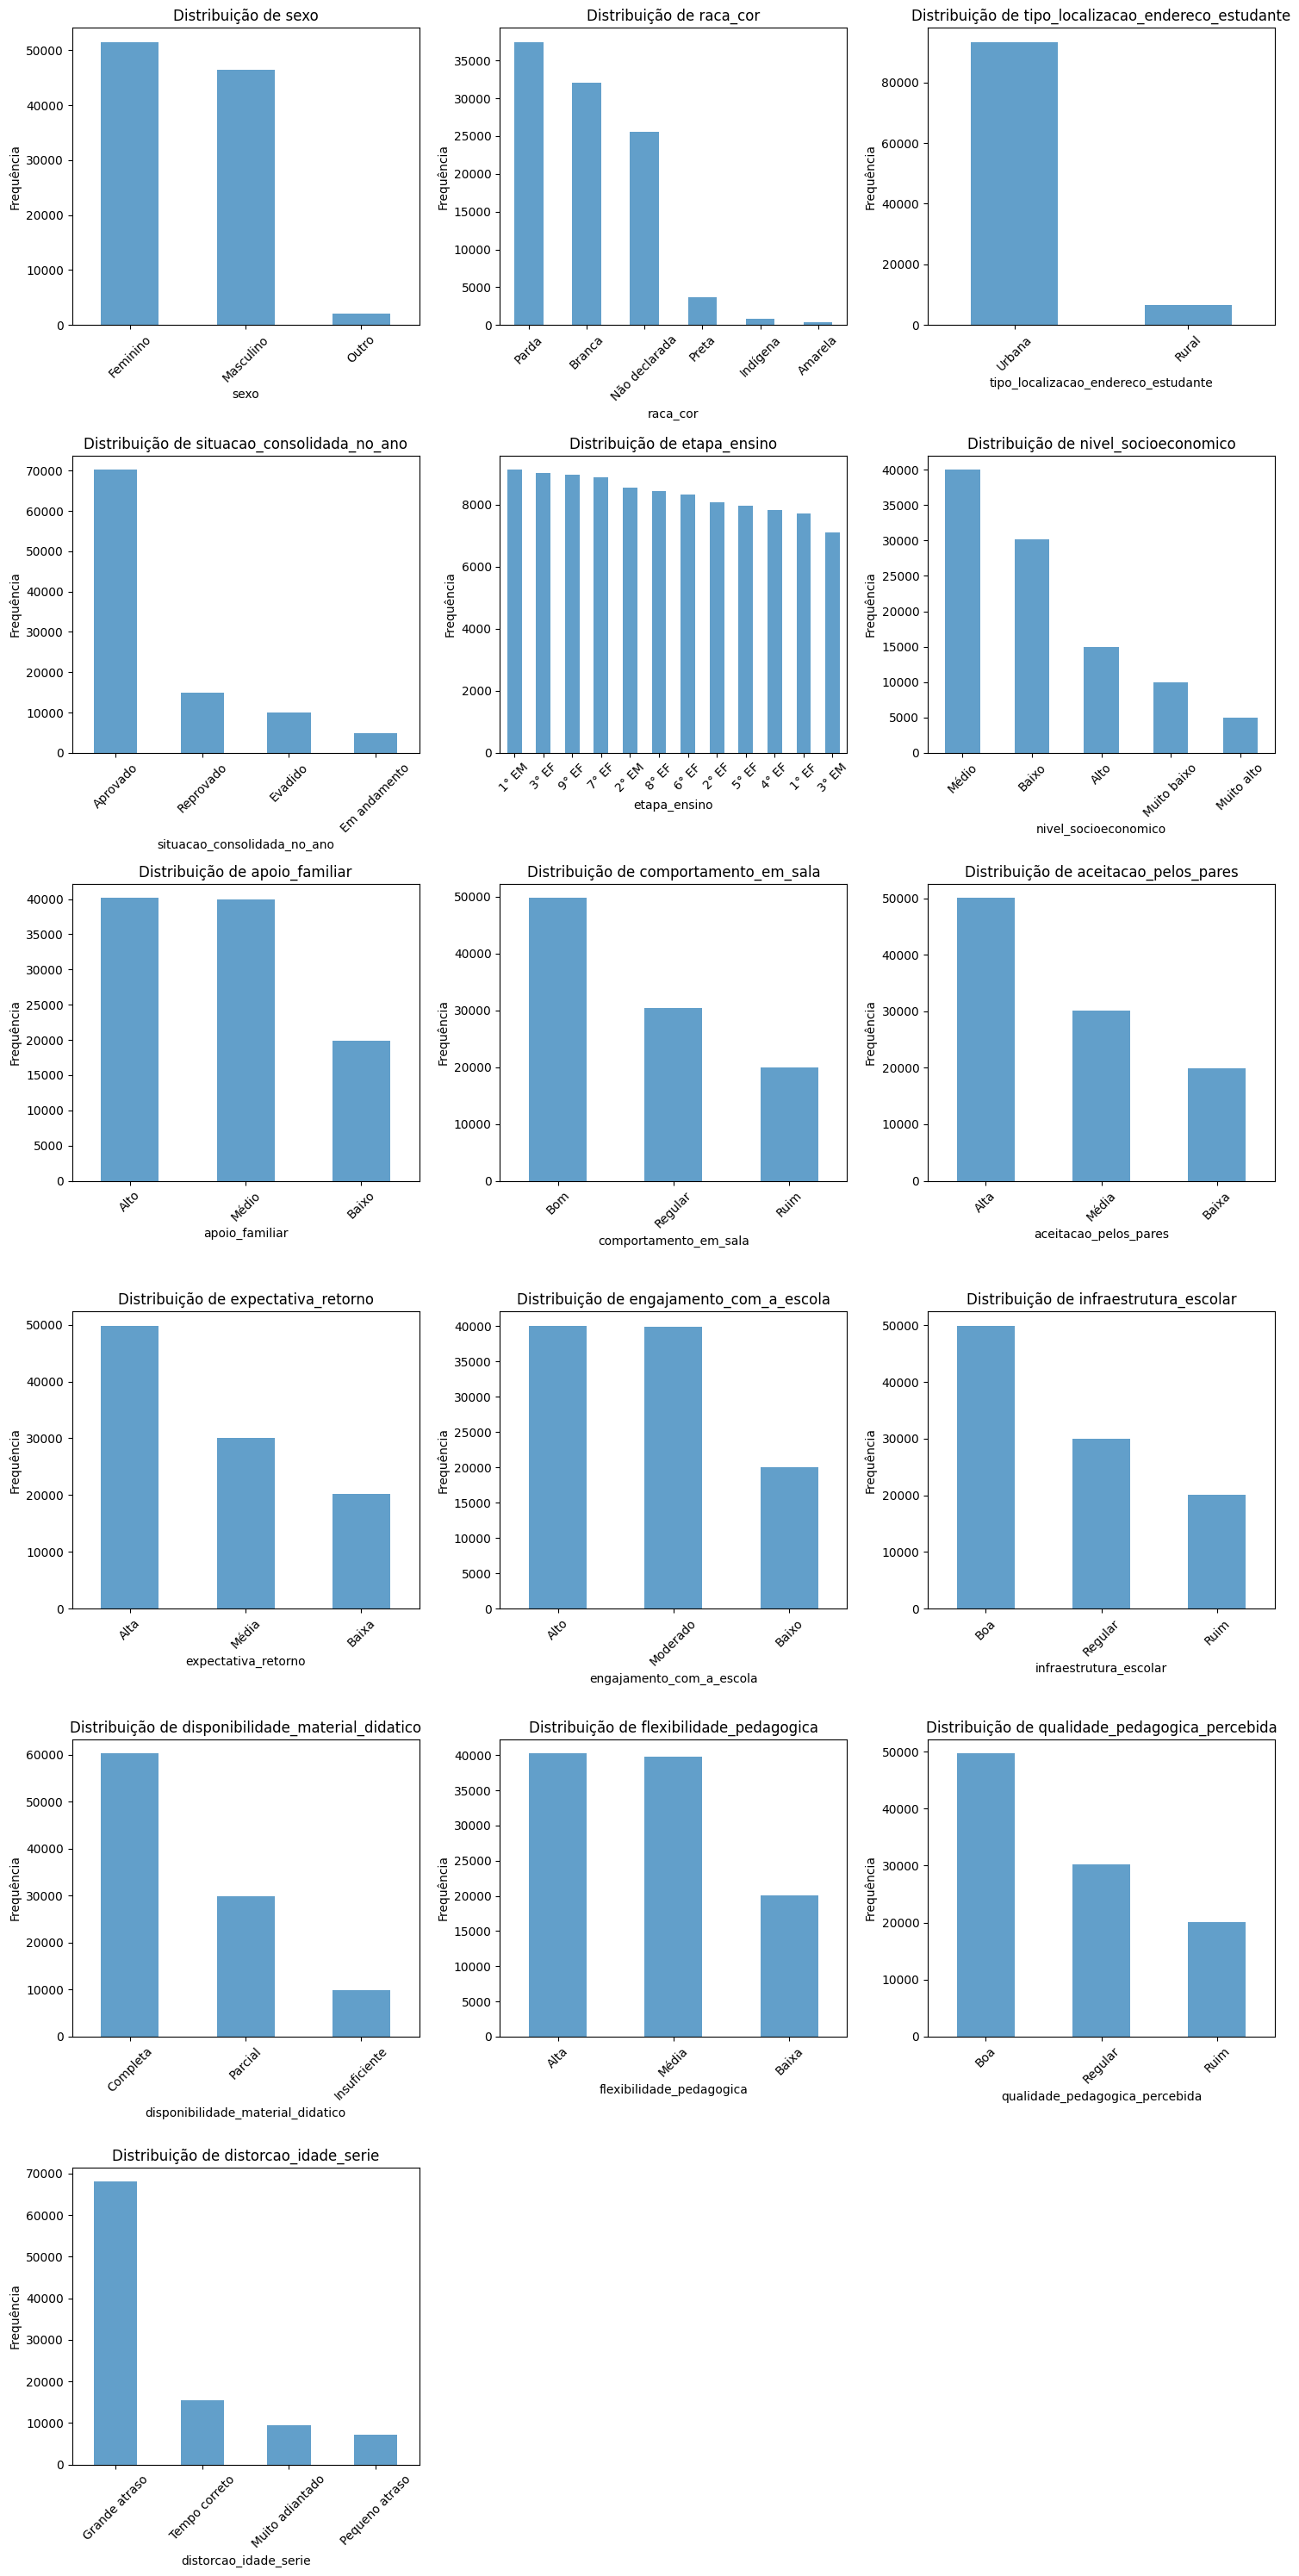

In [34]:
def plot_numerical_distributions(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3  # 3 colunas por linha
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
    
    # Remover subplots vazios
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Para variáveis categóricas (gráficos de barras)
def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
        axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Uso
plot_numerical_distributions(df)
plot_categorical_distributions(df)

Distribuições Numéricas:


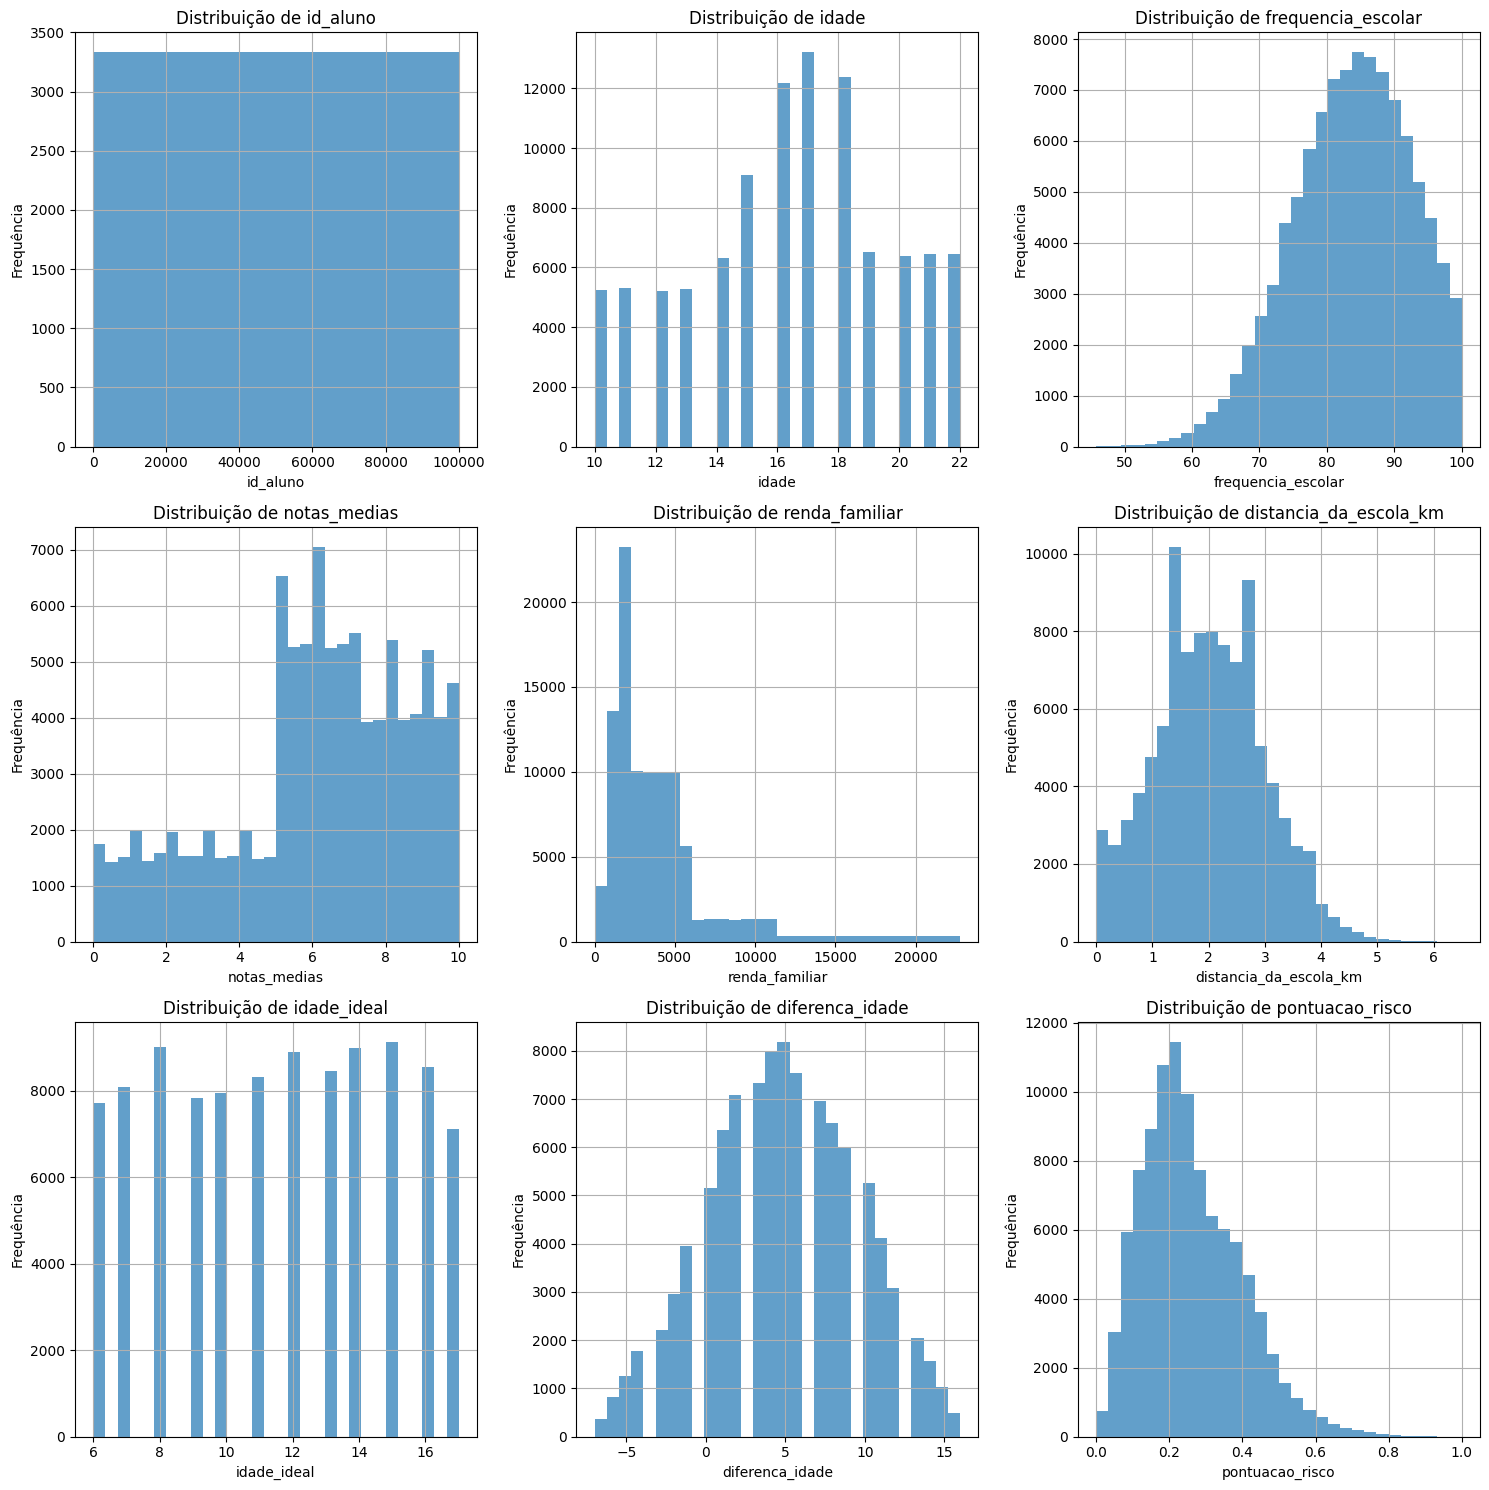


Distribuições Categóricas:


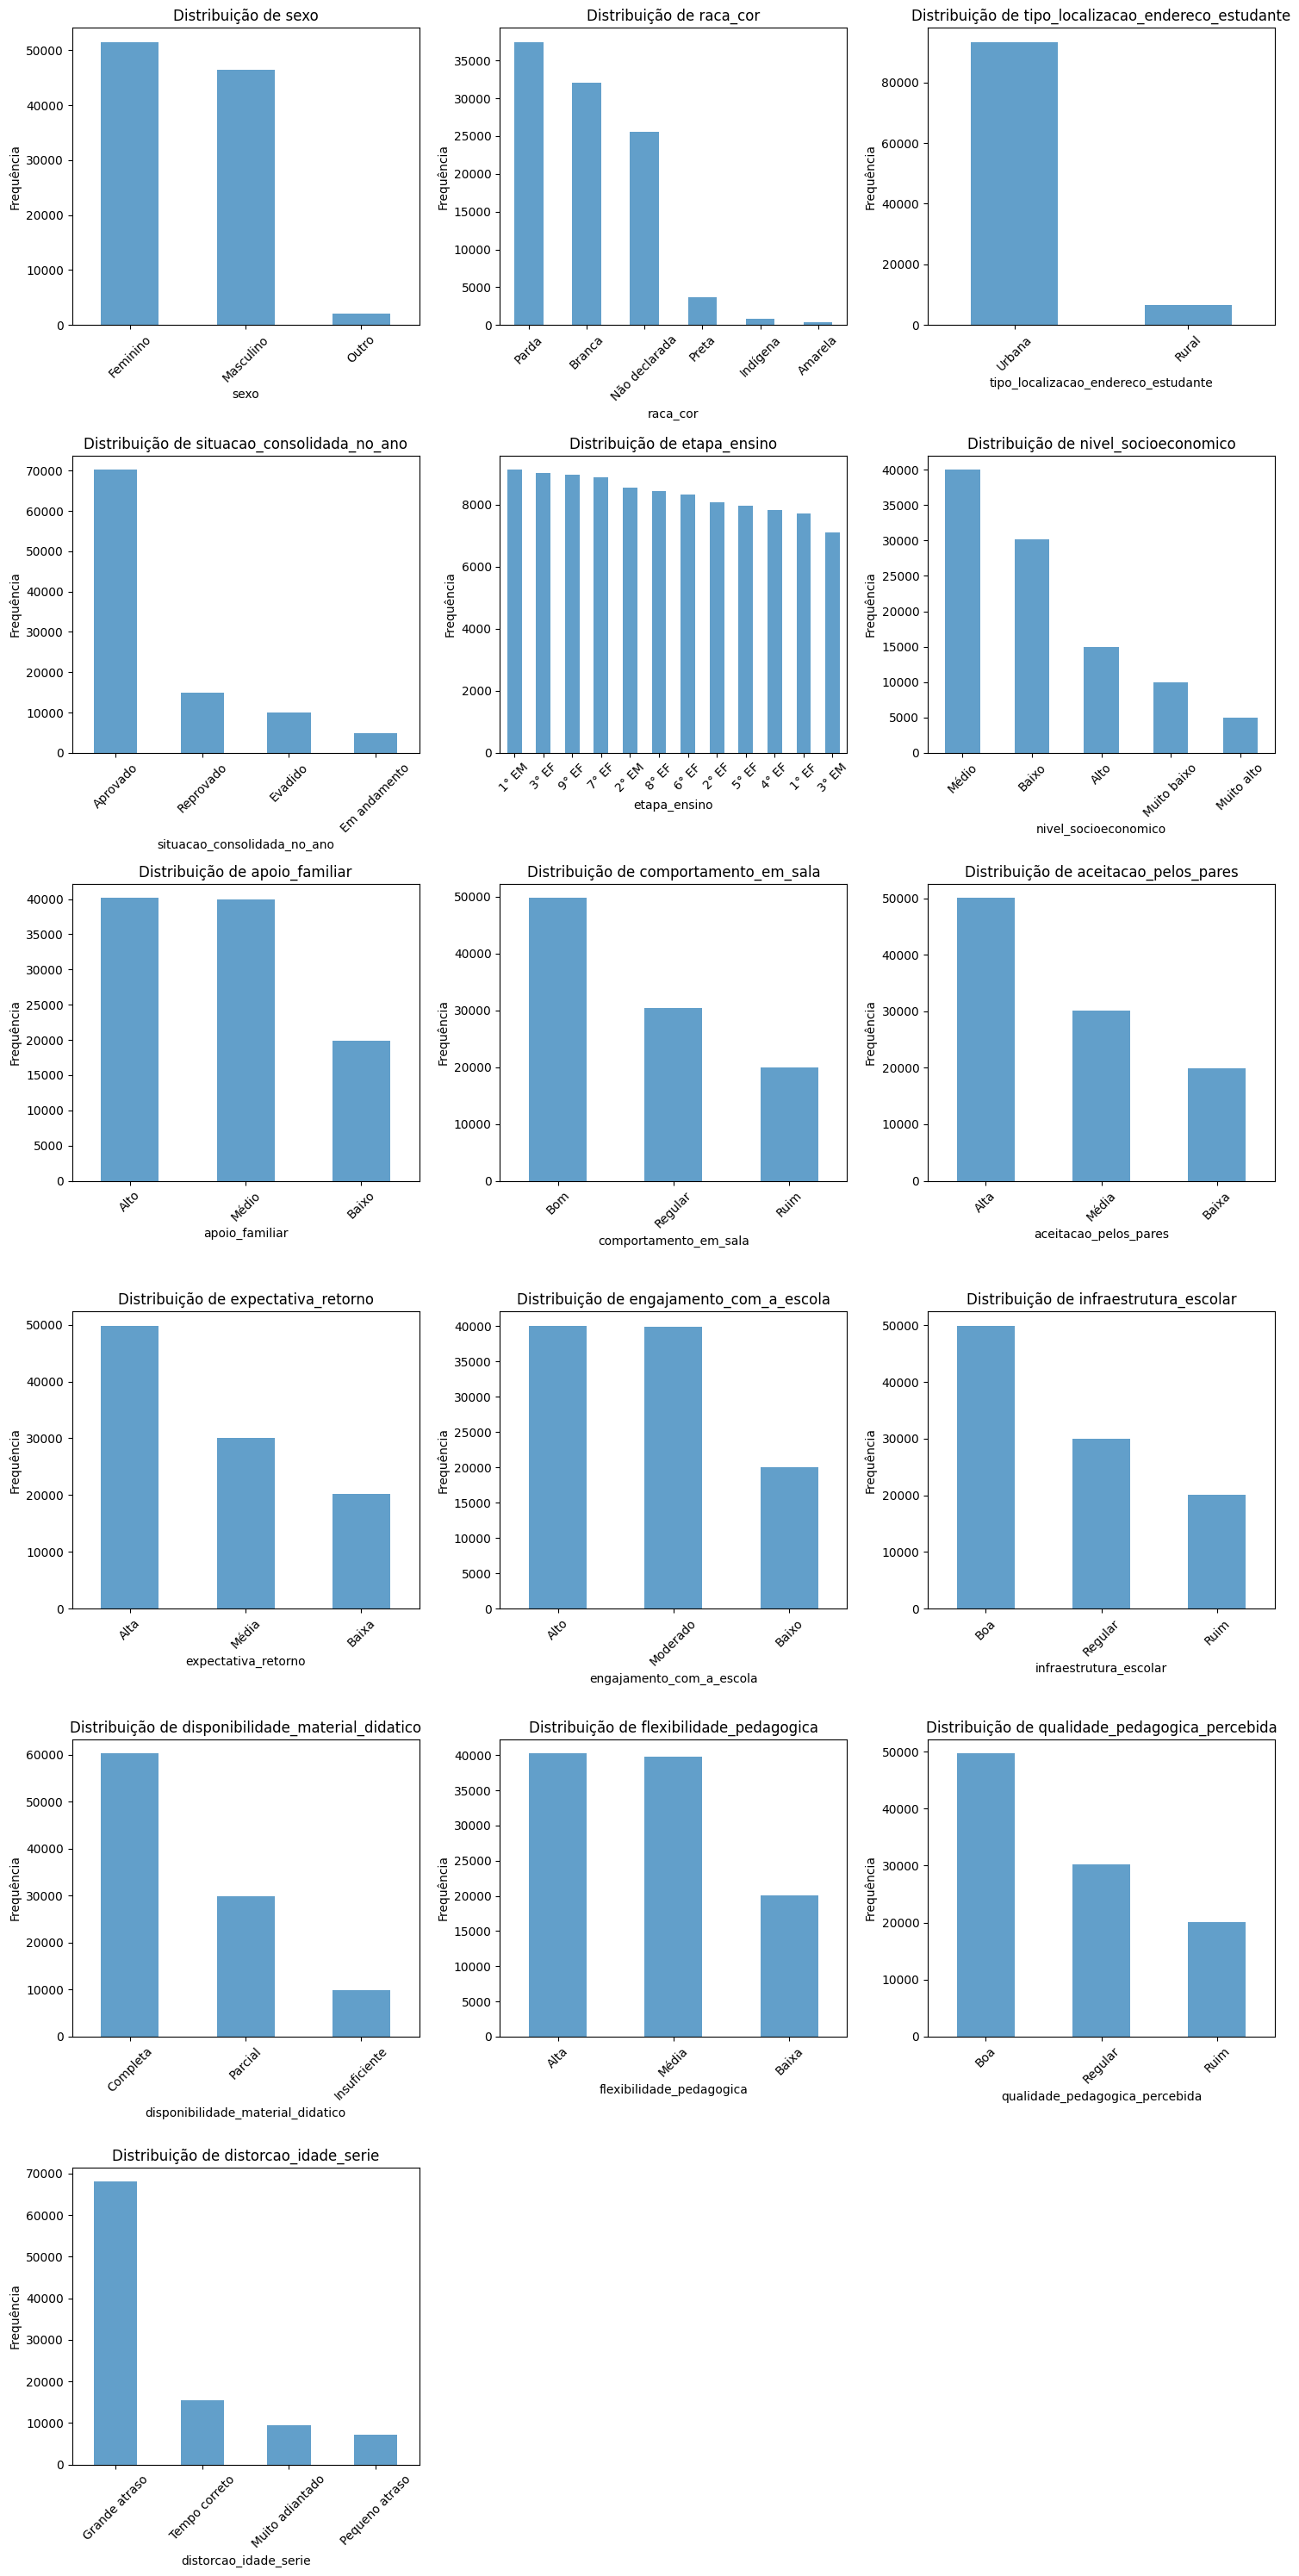

Análise de Evasão Escolar
Total de alunos: 100000
Taxa de evasão geral: 5.918%

Evasão por variáveis categóricas:

sexo:
  Masculino: 6.688%
  Outro: 5.917%
  Feminino: 5.223%

raca_cor:
  Parda: 5.993%
  Branca: 5.913%
  Não declarada: 5.897%
  Amarela: 5.764%
  Preta: 5.475%
  Indígena: 5.405%

nivel_socioeconomico:
  Muito baixo: 6.239%
  Médio: 5.937%
  Muito alto: 5.886%
  Baixo: 5.872%
  Alto: 5.755%

etapa_ensino:
  2° EM: 15.410%
  1° EM: 14.110%
  3° EM: 10.039%
  9° EF: 9.455%
  8° EF: 7.254%
  7° EF: 5.201%
  6° EF: 3.716%
  5° EF: 1.672%
  4° EF: 1.251%
  3° EF: 0.676%
  1° EF: 0.622%
  2° EF: 0.322%

distorcao_idade_serie:
  Pequeno atraso: 10.381%
  Tempo correto: 10.249%
  Muito adiantado: 5.787%
  Grande atraso: 4.488%

apoio_familiar:
  Baixo: 6.064%
  Médio: 6.023%
  Alto: 5.742%

=== INFORMAÇÕES DO DATASET ===
Dimensões: 100000 linhas x 40 colunas
Variáveis: 40
Taxa de evasão real: 5.918%


In [35]:
def analise_evasao(df):
    print("Análise de Evasão Escolar")
    print(f"Total de alunos: {len(df)}")
    print(f"Taxa de evasão geral: {df['evasao'].mean():.3%}")
    print("\nEvasão por variáveis categóricas:")
    
    variaveis_analise = ['sexo', 'raca_cor', 'nivel_socioeconomico', 'etapa_ensino', 
                        'distorcao_idade_serie', 'apoio_familiar']
    
    for var in variaveis_analise:
        if var in df.columns:
            evasao_por_var = df.groupby(var)['evasao'].mean().sort_values(ascending=False)
            print(f"\n{var}:")
            for categoria, taxa in evasao_por_var.items():
                print(f"  {categoria}: {taxa:.3%}")

# Gera visualizações
print("Distribuições Numéricas:")
plot_numerical_distributions(df)

print("\nDistribuições Categóricas:")
plot_categorical_distributions(df)

# Análise de evasão
analise_evasao(df)

# Informações do dataset
print(f"\n=== INFORMAÇÕES DO DATASET ===")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Variáveis: {len(df.columns)}")
print(f"Taxa de evasão real: {df['evasao'].mean():.3%}")

In [36]:
# Salvar dataset em CSV
df.to_csv('dataset_evasao_sintetico.csv', index=False)
print('Dataset salvo como dataset_evasao_sintetico.csv')

Dataset salvo como dataset_evasao_sintetico.csv
